In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.neighbors import NearestNeighbors
from PIL import Image
import random
import pandas as pd

In [10]:
embeddings = np.load('/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/embeddings/clip_embeddings.npy')
metadata = pd.read_csv('/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/metadata.csv')
metadata.head()

,image_path,group_id,transform,is_original,blurred,brightened,contrasted,cropped,original
0,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,original,1,0,0,0,0,1
1,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,blurred,0,1,0,0,0,0
2,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,brightened,0,0,1,0,0,0
3,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,contrasted,0,0,0,1,0,0
4,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,cropped,0,0,0,0,1,0


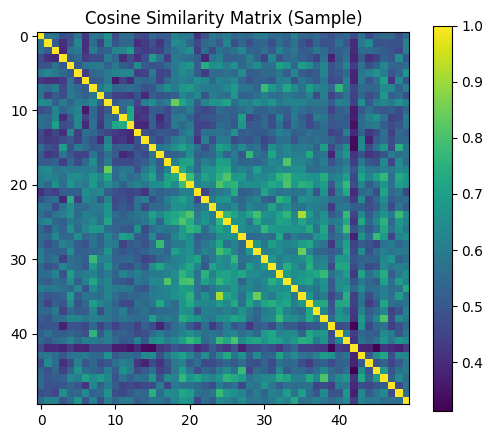

In [6]:
sample_size = 50
sample_idx = np.random.choice(len(embeddings), sample_size, replace=False)
sample_emb = embeddings[sample_idx]


cos_sim = cosine_similarity(sample_emb)


plt.figure(figsize=(6,5))
plt.imshow(cos_sim, cmap='viridis')
plt.title('Cosine Similarity Matrix (Sample)')
plt.colorbar()
plt.show()

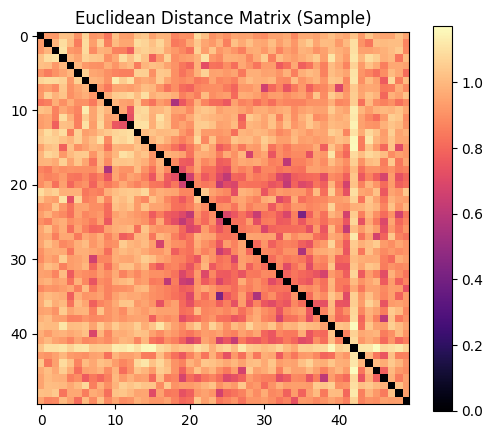

In [7]:
euc_dist = euclidean_distances(sample_emb)


plt.figure(figsize=(6,5))
plt.imshow(euc_dist, cmap='magma')
plt.title('Euclidean Distance Matrix (Sample)')
plt.colorbar()
plt.show()

In [8]:
k = 5
nn = NearestNeighbors(n_neighbors=k, metric='cosine')
nn.fit(embeddings)
dists, indices = nn.kneighbors(embeddings)


print('Distances shape:', dists.shape)
print('Indices shape:', indices.shape)

Distances shape: (30000, 5)
Indices shape: (30000, 5)


In [16]:
paths = metadata['image_path'].values

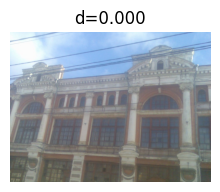

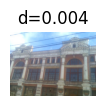

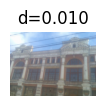

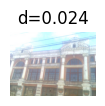

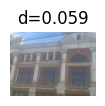

In [17]:
def show_knn(i, k=5):
    plt.figure(figsize=(15,3))
    for j, idx in enumerate(indices[i][:k]):
        img = Image.open(paths[idx])
        plt.subplot(1, k, j+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'd={dists[i][j]:.3f}')
        plt.show()

show_knn(random.randint(0, len(paths)-1))

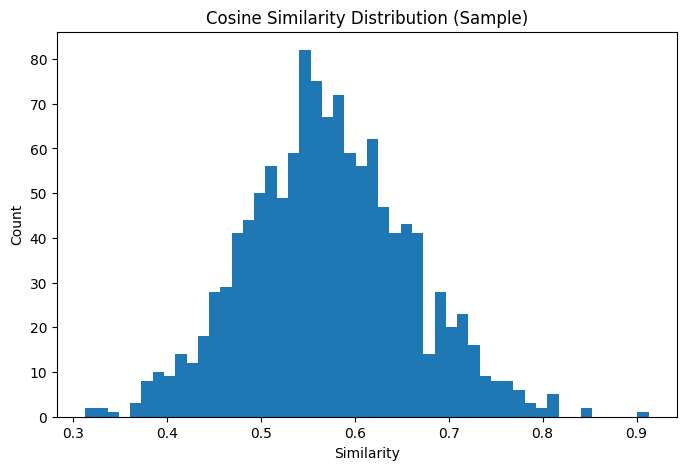

In [18]:
flat_sims = cos_sim[np.triu_indices_from(cos_sim, k=1)]


plt.figure(figsize=(8,5))
plt.hist(flat_sims, bins=50)
plt.title('Cosine Similarity Distribution (Sample)')
plt.xlabel('Similarity')
plt.ylabel('Count')
plt.show()

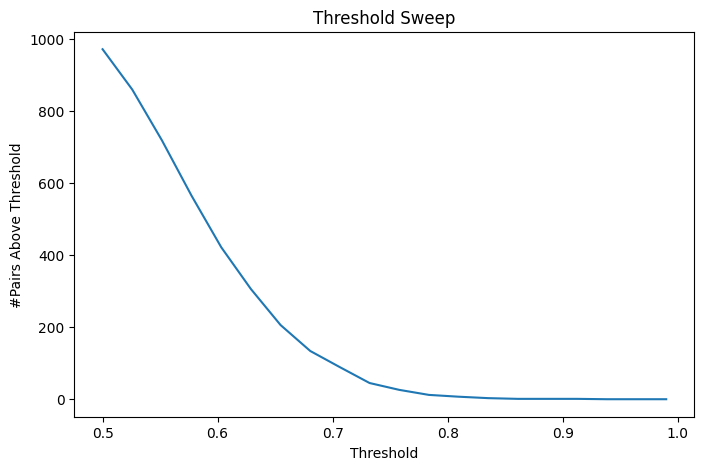

In [19]:
thresholds = np.linspace(0.5, 0.99, 20)
counts = []


for t in thresholds:
    counts.append(np.sum(flat_sims > t))


plt.figure(figsize=(8,5))
plt.plot(thresholds, counts)
plt.xlabel('Threshold')
plt.ylabel('#Pairs Above Threshold')
plt.title('Threshold Sweep')
plt.show()

In [22]:
THRESH = 0.82


pairs = []


for i in range(len(embeddings)):
    for j in indices[i][1:]: # skip self
        sim = cosine_similarity(embeddings[i].reshape(1,-1), embeddings[j].reshape(1,-1))[0][0]
        if sim > THRESH:
            pairs.append((i, j, sim))


print('Candidate duplicate pairs:', len(pairs))

Candidate duplicate pairs: 119851


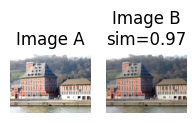

In [25]:
def show_pair(pair):
    i, j, sim = pair
    plt.figure(figsize=(6,3))


    img1 = Image.open(paths[i])
    img2 = Image.open(paths[j])


    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.axis('off')
    plt.title('Image A')


    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.axis('off')
    plt.title(f'Image B\nsim={sim:.2f}')

    plt.show()

show_pair(random.choice(pairs))